In [1]:
import dataset
import importlib
importlib.reload(dataset)
from dataset import DatasetCreation

In [2]:
import torch
import numpy as np 

In [3]:
# descarga de la Base de Datos 
data_list = torch.load("tsps.pt", weights_only=False)

In [4]:
ejemplo = data_list[13]
print
print("Nodos del problema:")
print(ejemplo.x.tolist())
print("\nAristas por donde pasa el tour (1 si para , 0 si no pasa):")
print(ejemplo.y.tolist())
print("\nCamino más corto")
print(ejemplo.true_path.tolist())
print("\nDistancia total del tour:")
print(ejemplo.true_distance.tolist())
print("\nPeso para la red neuronal:")
print(ejemplo.pos_class_weight)

Nodos del problema:
[[86.65316772460938, 44.298583984375], [97.84928894042969, 0.9275677800178528], [94.71952056884766, 97.0697250366211], [59.6941032409668, 5.331300735473633], [24.10684585571289, 55.332035064697266]]

Aristas por donde pasa el tour (1 si para , 0 si no pasa):
[[0.0], [0.0], [1.0], [0.0], [0.0], [1.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [1.0], [0.0], [1.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [1.0], [0.0]]

Camino más corto
[0.0, 2.0, 4.0, 3.0, 1.0]

Distancia total del tour:
[[279.9829406738281]]

Peso para la red neuronal:
4.0


In [5]:
import solutions
importlib.reload(dataset)
from solutions import SolutionAnalysys

In [6]:
#split the data to train, test, val

from torch_geometric.loader import DataLoader
import random

total_length = len(data_list)

# Calculate lengths of each part based on percentages
train_length = int(total_length * 0.7)
val_length = int(total_length * 0.1)

shuffled_list = random.sample(data_list, len(data_list))

# train, validate, test = np.split(data_list, [int(len(data_list)*0.7), int(len(data_list)*0.8)])
train_list = shuffled_list[:train_length]
val_list = shuffled_list[train_length:train_length + val_length]
test_list = shuffled_list[train_length + val_length:]

In [7]:
#to train the GNN with graphs of different sizes, we have to create batches with each batch having graphs of the same size.
#(Not sure there is another way for this)

max_batch_size = 256  # Maximum batch size
train_batched_data = []

# Sort the datasets based on the number of nodes
sorted_datasets = sorted(train_list, key=lambda x: x.num_nodes)

for dataset in sorted_datasets:
    if not train_batched_data or train_batched_data[-1][-1].num_nodes != dataset.num_nodes:
        # If the current batch is empty or the last dataset in the current batch has a different number of nodes,
        # start a new batch with the current dataset
        train_batched_data.append([dataset])
    else:
        # If adding the current dataset to the last batch doesn't exceed the maximum batch size,
        # add it to the last batch
        current_batch = train_batched_data[-1]
        if sum(data.num_nodes for data in current_batch) + dataset.num_nodes <= max_batch_size:
            current_batch.append(dataset)
        else:
            # Otherwise, start a new batch with the current dataset
            train_batched_data.append([dataset])

print(len(train_batched_data))

59


In [8]:
val_batched_data = []

# Sort the datasets based on the number of nodes
sorted_datasets = sorted(val_list, key=lambda x: x.num_nodes)

for dataset in sorted_datasets:
    if not val_batched_data or val_batched_data[-1][-1].num_nodes != dataset.num_nodes:
        # If the current batch is empty or the last dataset in the current batch has a different number of nodes,
        # start a new batch with the current dataset
        val_batched_data.append([dataset])
    else:
        # If adding the current dataset to the last batch doesn't exceed the maximum batch size,
        # add it to the last batch
        current_batch = val_batched_data[-1]
        if sum(data.num_nodes for data in current_batch) + dataset.num_nodes <= max_batch_size:
            current_batch.append(dataset)
        else:
            # Otherwise, start a new batch with the current dataset
            val_batched_data.append([dataset])

In [9]:
test_batched_data = []

# Sort the datasets based on the number of nodes
sorted_datasets = sorted(test_list, key=lambda x: x.num_nodes)

for dataset in sorted_datasets:
    if not test_batched_data or test_batched_data[-1][-1].num_nodes != dataset.num_nodes:
        # If the current batch is empty or the last dataset in the current batch has a different number of nodes,
        # start a new batch with the current dataset
        test_batched_data.append([dataset])
    else:
        # If adding the current dataset to the last batch doesn't exceed the maximum batch size,
        # add it to the last batch
        current_batch = test_batched_data[-1]
        if sum(data.num_nodes for data in current_batch) + dataset.num_nodes <= max_batch_size:
            current_batch.append(dataset)
        else:
            # Otherwise, start a new batch with the current dataset
            test_batched_data.append([dataset])

In [10]:
#create the data loaders

from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_batched_data, batch_size=None, shuffle=True)
val_loader = DataLoader(val_batched_data, batch_size=None, shuffle=True)
test_loader = DataLoader(test_batched_data, batch_size=None, shuffle=True)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.transforms as T
from torch.nn import Sequential as Seq, Linear as Lin, ReLU, BatchNorm1d
from torch_geometric.utils import scatter
from torch_geometric.nn import MetaLayer
from torch import Tensor

from typing import Optional, Tuple

'''
Toma los embeedings de los nods conectados pr una arista y los atributps actuales de esa arista, los concatena, 
los pasa por un MLP y produce una nueva respresentación de la arista. 
'''

class EdgeModel(torch.nn.Module):
    def __init__(self,hidden_dim):
        super().__init__()
        # Multiplicamos el vector por 3 debido a que es una concatenación de 3 vectores de la info de cada nodo: 
        #  1. src: Representación del nodo origen. 
        #  2. dst: Representación del nodo destino. 
        #  3. edge_attr: atributos actuales de la arista. 
        in_channels = ( 3 * hidden_dim )

        # Red Neuronal pequeña, de una capa: BatchNorm1d(3 * hidden_dim) -> Relu() -> Linear(hidden_dim)
        self.edge_mlp = Seq(BatchNorm1d(in_channels),
                            ReLU(),
                            Lin(in_channels, hidden_dim,bias=False))

    # Actualiza la información de los nodos 
    def forward(self, src, dst, edge_attr, edge_weight, u,  batch):
        out = torch.cat([src, edge_attr,dst], 1)

        return self.edge_mlp(out) + edge_attr # transforma la arista usando MLP y lo suma a la representación original.
    

'''
Actualiza cada nodo en función de la información que recibe desde sus vecinos (a través de las aristas conectadas)
y sus propios atributos. 
'''
class NodeModel(torch.nn.Module):
    def __init__(self,hidden_dim):
        super().__init__()
        # Concatena 2 vectores de tamaño hidden_dim. 
        # Caso mlp1:  
        #  1. x[row]: representación del nodo origen de cada arista. 
        #  2. edge_attr: representación de la arista. 
        # Caso mlp2: 
        #  1. x: representación original del nodo. 
        #  2. out: vector de agregar los mensajes de los nodos vecinos. 

        in_channels = ( 2 * hidden_dim)

        
        self.node_mlp_1 = Seq(BatchNorm1d(in_channels),
                              ReLU(),
                              Lin(in_channels, hidden_dim)
                              )
        self.node_mlp_2 = Seq(BatchNorm1d(in_channels),
                              ReLU(),
                              Lin(in_channels, hidden_dim))

    def forward(self, x, edge_index, edge_attr, edge_weight, u, batch):
        # x: Representación de los nodos
        # edge_index: qué nodos están conectados 
        # edge_attr: Representación de las aristas 
        # edge_weight: Peso de cada arista 

        # Nodos de origen y destino 
        row, col = edge_index

        '''Información agragada desde nodos vecinos '''
        # Calcula el mensaje que manda el nodo origen al nodo destino. 
        out = torch.cat([x[row], edge_attr], dim=1)
        out = self.node_mlp_1(out)

        # Junta todos los mensajes que le llegan al nodo destino y hace una media ponderada. 
        out = scatter(edge_weight*out, col, dim=0, dim_size=x.size(0), reduce='mean')
        out = torch.cat([x, out], dim=1)
        # out = torch.cat([x, out, u[batch]], dim=1)

        return self.node_mlp_2(out) + x
    

'''
Actualiza la representación global del grafo completo, genera un vector resumen del grafo entero.
'''
class GlobalModel(torch.nn.Module):
    def __init__(self,hidden_dim):
        super().__init__()
        in_channels = ( 2 * hidden_dim)
        # 1. u: estado global anterior del grafo
        # 2. resumen actual de los nodos del grafo 


        self.global_mlp = Seq(BatchNorm1d(in_channels),
                            ReLU(),
                            Lin(in_channels, hidden_dim,bias=False))

    def forward(self, x, edge_index, edge_attr, u, batch):
        # x: Representación de los nodos
        # edge_index: qué nodos están conectados 
        # edge_attr: Representación de las aristas 
        # edge_weight: Peso de cada arista 
        # u: Atributo global del grafo 
        # batch: A qué grafo pertenece cada nodo 


        # Calcula el promedio de los nodos del mismo grafo 
        out = torch.cat([
            u,
            scatter(x, batch, dim=0, reduce='mean'),
        ], dim=1)
        return self.global_mlp(out) + u # Actualiza el vector global que pasa por un MLP y se le suma el valor anterior u. 
    

'''
Capa de la GNN compuesta por: EdgeModel, NodeModel y GlobalMode.
'''
class MetaLayer(torch.nn.Module):

    # Llamadas a los módulos explicados antes 
    def __init__(self,edge_model,node_model,global_model):
        super(MetaLayer, self).__init__()
        self.edge_model = edge_model
        self.node_model = node_model
        self.global_model = global_model

    def forward(
        self,
        x: Tensor,
        edge_index: Tensor,
        edge_attr: Optional[Tensor] = None,
        edge_weight: Optional[Tensor] = None,
        u: Optional[Tensor] = None,
        batch: Optional[Tensor] = None,
    ) -> Tuple[Tensor, Optional[Tensor], Optional[Tensor]]:
        r"""Paso hacia adelante (forward pass).

        Parámetros:
            x (torch.Tensor): Las características de los nodos.
            edge_index (torch.Tensor): Los índices de las aristas.
            edge_attr (torch.Tensor, opcional): Las características de las aristas.
                (por defecto: None)
            edge_weight (torch.Tensor, opcional): El peso de cada arista (vector escalar).
                (por defecto: None)
            u (torch.Tensor, opcional): Las características globales del grafo.
                (por defecto: None)
            batch (torch.Tensor, opcional): El vector de agrupamiento (batch),
                :math:`\mathbf{b} \in {\{ 0, \ldots, B-1\}}^N`, que asigna
                cada nodo a un grafo específico. (por defecto: None)
        """
        row = edge_index[0]
        col = edge_index[1]

        # Calcular los nuevos atributos de las aristas
        if self.edge_model is not None:
            edge_attr = self.edge_model(x[row], x[col], edge_attr, edge_weight, u,
                                        batch if batch is None else batch[row])

        # Actuliza los nodos, en función de: estado actual, mensajes de vecinos(aristas), contexto global
        if self.node_model is not None:
            x = self.node_model(x, edge_index, edge_attr, edge_weight, u, batch)

        # Actualiza el grafo, calcula una nueva representación glrbal del grafo.
        if self.global_model is not None:
            u = self.global_model(x, edge_index, edge_attr, u, batch)

        return x, edge_attr, u # nodos, aristas y vector del grafo completo



'''
Definición de la GNN: 
    1. Preprocesamiento de los nodos
    2. Dos capas de propagación de mensajes: MetaLayer
    3. Decodificador que predice para cada arista si forma ara del tour 
    4. Capa final que pone una puntuación a cada arista. 
'''
class METALAYER_TSP_SOLVER(torch.nn.Module):

    # Transfromación de los datos 
    def __init__(self,node_input_dim, edge_input_dim, hidden_dim, decoder ='edge_emb', use_edge_weight=True):
        super(METALAYER_TSP_SOLVER, self).__init__()
        self.lin0_edge = Seq(Lin(edge_input_dim, hidden_dim,bias=False),BatchNorm1d(hidden_dim),ReLU()) 
        self.lin0_node = Seq(Lin(node_input_dim, hidden_dim,bias=False),BatchNorm1d(hidden_dim),ReLU())

        # Decodifadores 
        self.edge_lin1 = Lin((hidden_dim), hidden_dim) # embeddings de aristas 
        self.node_lin1 = Lin((hidden_dim*2), hidden_dim) # embeddings de nodos 
        self.nodes_edge_lin1 = Lin((hidden_dim*3), hidden_dim) # nodo1 + arista + nodo2
        self.lin2 = Lin(hidden_dim, 1) #Salida final

        # Parámetros de Control 
        self.decoder = decoder 
        self.use_edge_weight=use_edge_weight # Pesos de las aristas 

        '''Capas de MetaLayer'''
        self.metalayer = MetaLayer(EdgeModel(hidden_dim), NodeModel(hidden_dim),  None)
        self.metalayer2 = MetaLayer(EdgeModel(hidden_dim), NodeModel(hidden_dim),  None)


    def forward(self, x, edge_index, edge_attr, edge_weight, u, batch):
        edge_attr = self.lin0_edge(edge_attr)
        x = self.lin0_node(x)

        # Normalización de datos 
        if self.use_edge_weight==True and edge_weight is not None:
            edge_weight = torch.ones(edge_attr.shape[0],1)

        # Propagación de mensajes 
        x, edge_attr, u = self.metalayer(x, edge_index, edge_attr, edge_weight, None, batch)
        x, edge_attr, u = self.metalayer2(x, edge_index, edge_attr, edge_weight, None, batch)


        # En función delvalor de self.decoder, se decide cómo predecir si una arista está en el tour 
        if  self.decoder=='edge_emb': # solo usa las aristas 
            out = self.edge_lin1(edge_attr)
            
        elif self.decoder=='nodes_emb': # solo usa los nodos 
            row, col = edge_index
            z = torch.cat([x[row], x[col]], dim=-1)
            out = self.node_lin1(z)

        elif self.decoder=='edge_nodes_emb': # combina nodos y aristas 
            row, col = edge_index
            z = torch.cat([x[row], edge_attr, x[col]], dim=-1)
            out = self.nodes_edge_lin1(z)

        elif self.decoder=='node_inner_product': # producto interno entre nodos 
            row, col = edge_index
            out = (x[row]*x[col]).sum(dim=1).unsqueeze(1)

        elif self.decoder=='cond_node_inner_product': # producto interno entre nodos con contexto 
            row, col = edge_index
            out = x[row]
            out = scatter(edge_weight*out, col, dim=0, dim_size=x.size(0),
                      reduce='mean')
            out = torch.cat([x, out], dim=-1)
            out = (out[row]*out[col]).sum(dim=1).unsqueeze(1)

        else:
            raise ValueError('Possible decoders are edge_emb, nodes_emb, edge_nodes_emb, node_inner_product, and cond_node_inner_product')

        if "inner_product" not in self.decoder:
            out = self.lin2(out)

        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


edge_input_dim = 1
node_input_dim = 2
hidden_dim = 128 # Tamañao del vector que representa cada nodo 

use_edge_weight = True

num_epochs=32 

model = METALAYER_TSP_SOLVER(node_input_dim,
                             edge_input_dim, 
                             hidden_dim, 
                             decoder="edge_nodes_emb",
                             use_edge_weight=use_edge_weight
                            )
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.00005)

criterion = torch.nn.BCEWithLogitsLoss(reduction='none')

pytorch_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Number of parameters: {pytorch_total_params}')

Number of parameters: 333185


In [ ]:
import torch
import itertools
from torchinfo import summary


# === PARÁMETROS DEL MODELO ===
node_input_dim = 2
edge_input_dim = 1
hidden_dim = 128
use_edge_weight = True

# === INSTANCIAR MODELO ===
model = METALAYER_TSP_SOLVER(node_input_dim=node_input_dim,
                             edge_input_dim=edge_input_dim,
                             hidden_dim=hidden_dim,
                             decoder="edge_nodes_emb",  # Puedes probar otros: 'node_inner_product', etc.
                             use_edge_weight=use_edge_weight
                            )

# === CREAR ENTRADAS DE EJEMPLO ===
num_nodes = 12
num_edges = num_nodes * (num_nodes - 1)  # grafo dirigido completo

x = torch.rand((num_nodes, node_input_dim))
edge_index = torch.tensor(list(itertools.permutations(range(num_nodes), 2)), dtype=torch.long).T
edge_attr = torch.rand((num_edges, edge_input_dim))
edge_weight = torch.ones((num_edges, 1))
batch = torch.zeros(num_nodes, dtype=torch.long)

# === MOSTRAR ESTRUCTURA DEL MODELO ===
u = torch.zeros(1, hidden_dim)

summary(
    model,
    input_data=(x, edge_index, edge_attr, edge_weight, u, batch),
    depth=4,           # Controla cuántos niveles de módulos muestra
    col_names=["input_size", "output_size", "num_params"],
    col_width=20,
    row_settings=["var_names"]
)

Layer (type (var_name))                       Input Shape          Output Shape         Param #
METALAYER_TSP_SOLVER (METALAYER_TSP_SOLVER)   [12, 2]              [132, 1]             49,408
├─Sequential (lin0_edge)                      [132, 1]             [132, 128]           --
│    └─Linear (0)                             [132, 1]             [132, 128]           128
│    └─BatchNorm1d (1)                        [132, 128]           [132, 128]           256
│    └─ReLU (2)                               [132, 128]           [132, 128]           --
├─Sequential (lin0_node)                      [12, 2]              [12, 128]            --
│    └─Linear (0)                             [12, 2]              [12, 128]            256
│    └─BatchNorm1d (1)                        [12, 128]            [12, 128]            256
│    └─ReLU (2)                               [12, 128]            [12, 128]            --
├─MetaLayer (metalayer)                       [12, 128]            [12, 128] 

In [19]:
def train(train_loader):
    model.train()
    l1_path_distances = 0
    l1_optimality_gaps = 0

    for train_data in train_loader:  # Iterate in batches over the training dataset.
        train_data.x = train_data.x.to(device)
        train_data.edge_index= train_data.edge_index.to(device)
        train_data.edge_attr = train_data.edge_attr.to(device)
        train_data.edge_weight = train_data.edge_weight.to(device)
        train_data.batch = train_data.batch.to(device)
        global_model_x=train_data.pos_class_weight.unsqueeze(1).to(device)
        out = model(train_data.x, train_data.edge_index,train_data.edge_attr, train_data.edge_weight, None, train_data.batch)  # Perform a single forward pass.
        train_loss = criterion(out, train_data.y.to(device))  # Compute the loss.

        batch_weights = torch.ones(train_loss.shape)

        mask = train_data.y.bool()  # Add a dimension to match the shape of ones_tensor
        batch_weights[mask.squeeze()] *= train_data.pos_class_weight[0]

        train_loss = train_loss * batch_weights.to(device)
        train_loss = train_loss.sum() / batch_weights.sum()

        train_loss.backward()  # Derive gradients.
        optimizer.step()  # Update parameters based on gradients.
        optimizer.zero_grad()  # Clear gradients.

        for_view = int(train_data.num_nodes/train_data.num_graphs)
        batch_out_heat_map=out.view((train_data.num_graphs, for_view,for_view))
        batch_truth_heat_map=train_data.true_path.view((train_data.num_graphs, for_view))
        batch_edge_weights=train_data.edge_weight.view((train_data.num_graphs, for_view, for_view))
        batch_true_distancess =  train_data.true_distance.view((train_data.num_graphs))

        l1_path_distance, l1_gap = SolutionAnalysys.mean_per_batch_optimality_metrics(batch_out_heat_map, batch_truth_heat_map, train_data.num_graphs,  for_view, batch_edge_weights,batch_true_distancess)
        l1_path_distances += l1_path_distance
        l1_optimality_gaps += l1_gap

    return train_loss, l1_path_distances/len(train_loader), l1_optimality_gaps/len(train_loader)

def test(loader):
    model.eval()
    l1_path_distances = 0
    l1_optimality_gaps = 0

    for test_data in loader:  # Iterate in batches over the training dataset.
        test_data.x = test_data.x.to(device)
        test_data.edge_index= test_data.edge_index.to(device)
        test_data.edge_attr = test_data.edge_attr.to(device)
        test_data.edge_weight = test_data.edge_weight.to(device)
        test_data.batch = test_data.batch.to(device)
        global_model_x=test_data.pos_class_weight.unsqueeze(1).to(device)
        out = model(test_data.x, test_data.edge_index,test_data.edge_attr, test_data.edge_weight, test_data.pos_class_weight.unsqueeze(1), test_data.batch)  # Perform a single forward pass.
        test_loss = criterion(out, test_data.y.to(device))  # Compute the loss.


        batch_weights = torch.ones(test_loss.shape).to(device)

        mask = test_data.y.bool()  # Add a dimension to match the shape of ones_tensor
        batch_weights[mask.squeeze()] *= test_data.pos_class_weight[0]

        test_loss = test_loss * batch_weights
        test_loss = test_loss.sum() / batch_weights.sum()


        for_view = int(test_data.num_nodes/test_data.num_graphs)

        batch_out_heat_map=out.view((test_data.num_graphs, for_view, for_view))
        batch_truth_heat_map=test_data.true_path.view((test_data.num_graphs, for_view))
        batch_edge_weights=test_data.edge_weight.view((test_data.num_graphs, for_view, for_view))
        batch_true_distancess =  test_data.true_distance.view((test_data.num_graphs))

        l1_path_distance, l1_gap = SolutionAnalysys.mean_per_batch_optimality_metrics(batch_out_heat_map, batch_truth_heat_map, test_data.num_graphs, for_view, batch_edge_weights,batch_true_distancess)
        l1_path_distances += l1_path_distance
        l1_optimality_gaps += l1_gap


    return test_loss, l1_path_distances/len(loader), l1_optimality_gaps/len(loader)

train_losses = []
test_losses = []
val_losses = []

train_l1_opt_gaps = []
test_l1_opt_gaps = []
val_l1_opt_gaps = []

for epoch in range(0, num_epochs+1):
    train_loss, train_l1_path_dist, train_opt_gap = train(train_loader)
    #we use the validation part also for training
    train_loss, train_l1_path_dist, train_opt_gap = train(val_loader)


    val_loss, val_l1_path_dist, val_opt_gap  = test(val_loader)

    test_loss, test_l1_path_dist, test_opt_gap  = test(test_loader)

    if epoch%5 ==0:
        print(f'Epoch: {(epoch+1):03d}')
        print(f'\t Train loss: {train_loss:.4f} L1 path dist: {train_l1_path_dist:.4f} opt. gap  {train_opt_gap:.4f}')
        print(f'\t Val loss: {val_loss:.4f} L1 path dist: {val_l1_path_dist:.4f} opt. gap  {val_opt_gap:.4f}')
        print(f'\t Test loss: {test_loss:.4f} L1 path dist: {test_l1_path_dist:.4f} opt. gap  {test_opt_gap:.4f}')
        print()

    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())
    val_losses.append(val_loss.item())

    train_l1_opt_gaps.append(train_opt_gap.item())
    test_l1_opt_gaps.append(test_opt_gap.item())
    val_l1_opt_gaps.append(val_opt_gap.item())


Epoch: 001
	 Train loss: 0.4654 L1 path dist: 8.0966 opt. gap  0.2343
	 Val loss: 0.4847 L1 path dist: 8.2726 opt. gap  0.2615
	 Test loss: 0.5097 L1 path dist: 7.7382 opt. gap  0.2301

Epoch: 006
	 Train loss: 0.4553 L1 path dist: 7.6038 opt. gap  0.1860
	 Val loss: 0.6827 L1 path dist: 7.6522 opt. gap  0.1809
	 Test loss: 0.4835 L1 path dist: 6.9530 opt. gap  0.1657

Epoch: 011
	 Train loss: 0.4106 L1 path dist: 6.5761 opt. gap  0.0962
	 Val loss: 0.3637 L1 path dist: 6.8911 opt. gap  0.0920
	 Test loss: 0.4299 L1 path dist: 5.9084 opt. gap  0.0839

Epoch: 016
	 Train loss: 0.3349 L1 path dist: 6.7999 opt. gap  0.0863
	 Val loss: 0.3408 L1 path dist: 6.3383 opt. gap  0.0732
	 Test loss: 0.4203 L1 path dist: 4.9928 opt. gap  0.0575

Epoch: 021
	 Train loss: 0.3432 L1 path dist: 6.1729 opt. gap  0.0728
	 Val loss: 0.3329 L1 path dist: 6.2247 opt. gap  0.0678
	 Test loss: 0.4592 L1 path dist: 5.2357 opt. gap  0.0602

Epoch: 026
	 Train loss: 0.3757 L1 path dist: 6.6260 opt. gap  0.0852


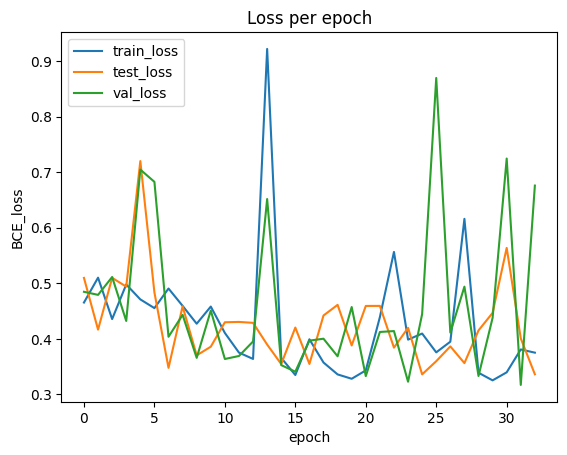

In [20]:
import matplotlib.pyplot as plt
# Plot the curves
plt.plot(train_losses,label='train_loss')
plt.plot(test_losses,label='test_loss')
plt.plot(val_losses,label='val_loss')
plt.xlabel('epoch')
plt.ylabel('BCE_loss')
plt.title('Loss per epoch')
plt.legend()
plt.show()

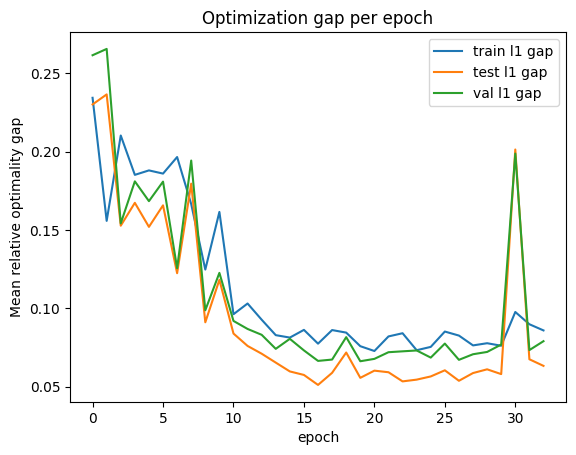

In [21]:
import matplotlib.pyplot as plt
# Plot the curves
plt.plot(train_l1_opt_gaps,label='train l1 gap')
plt.plot(test_l1_opt_gaps,label='test l1 gap')
plt.plot(val_l1_opt_gaps,label='val l1 gap')
plt.xlabel('epoch')
plt.ylabel('Mean relative optimality gap')
plt.title("Optimization gap per epoch")
plt.legend()
plt.show()

In [ ]:
from torch_geometric.utils import to_undirected,add_self_loops
from torch_geometric.data import Data
import itertools


new_data_list = []

num_datasets = 100

for num_nodes in [15]:
  node_coords, distance_matrices,solution_paths, solution_adjacencies, distances = DatasetCreation.create_dataset(num_nodes = num_nodes,  num_datasets = num_datasets)

  num_pos = num_nodes
  num_neg = num_nodes**2-num_nodes
  print(f'Number of solution edges {num_pos}')
  print(f'Number of false edges {num_neg} \n')


  weight_pos_class = (num_neg/num_pos)

  edge_index = torch.tensor(list(itertools.product(np.arange(num_nodes),np.arange(num_nodes))), dtype=torch.long).T.contiguous()
  for i in range(len(node_coords)):
      edge_attr = torch.tensor(((distance_matrices[i])).flatten()).float().unsqueeze(1)

      x = torch.tensor(node_coords[i]).float()
      y = torch.tensor(solution_adjacencies[i].flatten()).float().unsqueeze(1)


      data = Data(x=x, edge_index=edge_index, y= y, edge_attr=edge_attr)
      data.edge_weight = torch.tensor(((distance_matrices[i])).flatten()).float().unsqueeze(1)
      data.true_path = torch.Tensor(solution_paths[i])
      data.true_distance = torch.Tensor([distances[i]]).unsqueeze(1)
      data.num_nodes = num_nodes
      data.pos_class_weight = weight_pos_class
      new_data_list.append(data)



new_loader = DataLoader(new_data_list, batch_size=1, shuffle=False)

_, _, new_opt_gap = test(new_loader)

print(f'Mean relative opt. gap on new instances {new_opt_gap.item()}')

Number of solution edges 15
Number of false edges 210 

Mean relative opt. gap on new instances 0.17298850417137146


In [ ]:
import itertools
import torch
import os
import gc
import pandas as pd



# === Dispositivo ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Parámetros fijos ===
edge_input_dim = 1
node_input_dim = 2
use_edge_weight = True

# === Hiperparámetros a probar ===
hidden_dims = [128]
num_epochs_list = [32, 64] 
lrs = [0.001, 0.0005]
weight_decays = [0.0001, 0.00005]
decoders = ["edge_emb", "edge_nodes_emb"]


# === Carpeta para guardar modelos ===
save_dir = "trained_models"
os.makedirs(save_dir, exist_ok=True)

# === Resultados ===
results = []

# === Probar todas las configuraciones ===
configs = list(itertools.product(hidden_dims, num_epochs_list, lrs, weight_decays, decoders))

for i, (hidden_dim, num_epochs, lr, weight_decay, decoder) in enumerate(configs):
    print(f"\nEntrenando modelo {i+1}/{len(configs)}")
    print(f"→ hidden_dim={hidden_dim}, epochs={num_epochs}, lr={lr}, weight_decay={weight_decay}, decoder='{decoder}'")

    # === Crear modelo y objetos globales ===
    model = METALAYER_TSP_SOLVER(node_input_dim, edge_input_dim, hidden_dim, decoder=decoder, use_edge_weight=use_edge_weight).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss(reduction='none')

    # === Métricas por época ===
    train_losses = []
    val_losses = []
    test_losses = []
    train_l1_opt_gaps = []
    val_l1_opt_gaps = []
    test_l1_opt_gaps = []

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_l1_path_dist, train_opt_gap = train(train_loader)
        train_loss, train_l1_path_dist, train_opt_gap = train(val_loader)

        model.eval()
        val_loss, val_l1_path_dist, val_opt_gap = test(val_loader)
        test_loss, test_l1_path_dist, test_opt_gap = test(test_loader)

        if epoch % 5 == 0 or epoch == num_epochs - 1:
            print(f"Epoch: {(epoch+1):03d}")
            print(f"\t Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Test loss: {test_loss:.4f}")
            print(f"\t L1 path dist: Train {train_l1_path_dist:.4f} | Val {val_l1_path_dist:.4f} | Test {test_l1_path_dist:.4f}")
            print(f"\t Optimality gap: Train {train_opt_gap:.4f} | Val {val_opt_gap:.4f} | Test {test_opt_gap:.4f}")

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())
        test_losses.append(test_loss.item())
        train_l1_opt_gaps.append(train_opt_gap.item())
        val_l1_opt_gaps.append(val_opt_gap.item())
        test_l1_opt_gaps.append(test_opt_gap.item())

    # === Guardar modelo ===
    model_filename = f"model_{i+1}_hd{hidden_dim}_lr{lr}_ep{num_epochs}_dec_{decoder}.pt"
    model_path = os.path.join(save_dir, model_filename)
    torch.save(model.state_dict(), model_path)

    # === Guardar resumen final ===
    results.append({
        "modelo": i + 1,
        "hidden_dim": hidden_dim,
        "num_epochs": num_epochs,
        "lr": lr,
        "weight_decay": weight_decay,
        "decoder": decoder,
        "train_loss": train_losses[-1],
        "val_loss": val_losses[-1],
        "test_loss": test_losses[-1],
        "val_opt_gap": val_l1_opt_gaps[-1],
        "test_opt_gap": test_l1_opt_gaps[-1],
        "model_path": model_path
    })

    # === Limpiar para siguiente modelo ===
    del model, optimizer, criterion
    torch.cuda.empty_cache()
    gc.collect()

# === Guardar resumen a CSV ===
df = pd.DataFrame(results)
df.to_csv("resultados_entrenamiento.csv", index=False)
print("\n Entrenamiento completo. Resultados guardados en 'resultados_entrenamiento.csv'")



Entrenando modelo 1/16
→ hidden_dim=128, epochs=32, lr=0.001, weight_decay=0.0001, decoder='edge_emb'
Epoch: 001
	 Train loss: 0.4672 | Val loss: 0.5121 | Test loss: 0.5250
	 L1 path dist: Train 7.7291 | Val 8.4998 | Test 7.8299
	 Optimality gap: Train 0.1835 | Val 0.2569 | Test 0.2387
Epoch: 006
	 Train loss: 0.4627 | Val loss: 0.4991 | Test loss: 0.4276
	 L1 path dist: Train 7.5965 | Val 7.7709 | Test 7.1885
	 Optimality gap: Train 0.1810 | Val 0.1941 | Test 0.1663
Epoch: 011
	 Train loss: 0.4299 | Val loss: 0.3741 | Test loss: 0.6896
	 L1 path dist: Train 7.0149 | Val 6.4603 | Test 5.8870
	 Optimality gap: Train 0.1093 | Val 0.0810 | Test 0.0739
Epoch: 016
	 Train loss: 0.3544 | Val loss: 0.4637 | Test loss: 0.7591
	 L1 path dist: Train 6.7474 | Val 6.8320 | Test 5.4037
	 Optimality gap: Train 0.0893 | Val 0.0812 | Test 0.0666
Epoch: 021
	 Train loss: 0.3848 | Val loss: 0.3587 | Test loss: 0.7669
	 L1 path dist: Train 6.5387 | Val 6.4904 | Test 5.4761
	 Optimality gap: Train 0.0890

In [ ]:
import os
import torch
import pandas as pd


# === Carga el CSV con tus resultados previos ===
df = pd.read_csv("resultados_entrenamiento_GNN.csv")

records = []

for _, row in df.iterrows():
    hidden_dim = int(row["hidden_dim"])
    decoder    = row["decoder"]
    model_path = row["model_path"]

    # Reconstruye y carga el modelo en la variable global `model`
    model = METALAYER_TSP_SOLVER(
        node_input_dim=2,
        edge_input_dim=1,
        hidden_dim=hidden_dim,
        decoder=decoder,
        use_edge_weight=True
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))

    # Ahora `test(loader)` usará este `model`, tu `criterion` y `device`
    model.eval()
    with torch.no_grad():
        new_test_loss, new_test_l1_dist, new_test_opt_gap = test(test_loader)

    records.append({
        "modelo":           row["modelo"],
        "hidden_dim":       hidden_dim,
        "num_epochs":       int(row["num_epochs"]),
        "lr":               float(row["lr"]),
        "weight_decay":     float(row["weight_decay"]),
        "decoder":          decoder,
        "prev_test_loss":   float(row["test_loss"]),
        "new_test_loss":    new_test_loss.item(),
        "new_test_l1_dist": new_test_l1_dist,
        "new_test_opt_gap": new_test_opt_gap,
        "model_path":       model_path
    })

# Construye y ordena el DataFrame
comp_df = pd.DataFrame(records).sort_values("new_test_opt_gap")
print(comp_df.to_string(index=False))
comp_df.to_csv("comparacion_modelos.csv", index=False)
print("\nComparación guardada en 'comparacion_modelos.csv'")


 modelo  hidden_dim  num_epochs     lr  weight_decay        decoder  prev_test_loss  new_test_loss  new_test_l1_dist new_test_opt_gap                                                        model_path
      2         128          32 0.0010       0.00010 edge_nodes_emb        0.391352       0.433235          5.196194   tensor(0.0544)   trained_models\model_2_hd128_lr0.001_ep32_dec_edge_nodes_emb.pt
      6         128          32 0.0005       0.00010 edge_nodes_emb        0.373398       0.789424          5.262586   tensor(0.0564)  trained_models\model_6_hd128_lr0.0005_ep32_dec_edge_nodes_emb.pt
      8         128          32 0.0005       0.00005 edge_nodes_emb        0.390088       0.459575          5.257847   tensor(0.0568)  trained_models\model_8_hd128_lr0.0005_ep32_dec_edge_nodes_emb.pt
     12         128          64 0.0010       0.00005 edge_nodes_emb        0.391036       0.411499          5.107666   tensor(0.0577)  trained_models\model_12_hd128_lr0.001_ep64_dec_edge_nodes_emb.pt


c:\Users\6003384\Desktop\REPOSITORIOS\TSP_Classical_Solutions\tsp-venv\Lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Ruta óptima real:    [0, 5, 7, 6, 4, 1, 2, 9, 8, 3, 0]
Longitud real:       299.2992755042442
Ruta predicha:       [0, 5, 1, 3, 2, 9, 8, 4, 6, 7, 0]
Longitud predicha:   334.0956626240854
Optimality gap:     11.63%


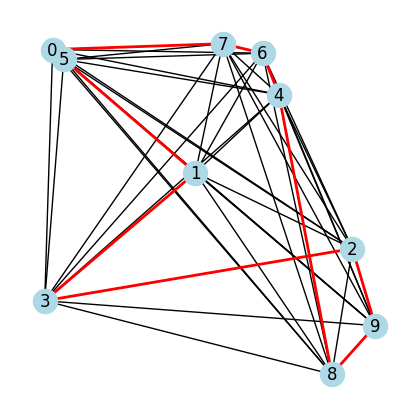

In [56]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import Data, DataLoader

# 1) Genera UNA instancia TSP de ejemplo
num_nodes = 10
# genera un solo dataset: devuelve listas de longitud 1
node_coords, distance_matrices, solution_paths, solution_adjacencies, distances = \
    DatasetCreation.create_dataset(num_nodes=num_nodes, num_datasets=1)

coords = torch.tensor(node_coords[0], dtype=torch.float)           # [N,2]
dist_mat = distance_matrices[0]                                    # [N,N]
true_path = solution_paths[0]                                      # lista de nodos ordenados
true_distance = distances[0]                                       # float

# 2) Construye el Data de PyG
edges, dists = [], []
for i in range(num_nodes):
    for j in range(num_nodes):
        if i==j: continue
        edges.append([i,j])
        dists.append([dist_mat[i,j]])
edge_index  = torch.tensor(edges, dtype=torch.long).t().contiguous()
edge_attr   = torch.tensor(dists, dtype=torch.float)
edge_weight = edge_attr.clone()
batch       = torch.zeros(num_nodes, dtype=torch.long)

data = Data(
    x=coords,
    edge_index=edge_index,
    edge_attr=edge_attr,
    edge_weight=edge_weight,
    true_path=torch.tensor(true_path, dtype=torch.long),
    true_distance=torch.tensor([true_distance], dtype=torch.float),
    pos_class_weight=( (num_nodes**2 - num_nodes)/num_nodes )
)

loader = DataLoader([data], batch_size=1)

# 3) Carga tu modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = METALAYER_TSP_SOLVER(2,1,128,decoder="edge_nodes_emb",use_edge_weight=True).to(device)
model.load_state_dict(torch.load("trained_models/model_2_hd128_lr0.001_ep32_dec_edge_nodes_emb.pt", map_location=device))
model.eval()

# 4) Inferencia + evaluación
with torch.no_grad():
    batch = next(iter(loader)).to(device)
    logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.edge_weight, None, batch.batch)  # [E,1]
    probs = torch.sigmoid(logits).view(-1)

    # Reconstruye tour greedy sobre top-N aristas
    N = num_nodes
    pairs = list(zip(batch.edge_index.t().cpu().tolist(), probs.cpu().numpy()))
    pairs.sort(key=lambda x: -x[1])
    top_edges = [e for e,_ in pairs[:N]]

    # construir tour Hamiltoniano
    tour = [0]; visited={0}
    while len(tour)<N:
        cur=tour[-1]
        for i,j in top_edges:
            if i==cur and j not in visited:
                tour.append(j); visited.add(j); break
        else:
            rem = set(range(N))-visited
            nxt = rem.pop()
            tour.append(nxt); visited.add(nxt)
    tour.append(tour[0])

    # calcula métricas
    # convierte top_edges en heat map para SolutionAnalysys
    # (o simplemente calcula longitud y gap directamente)
    # Aquí calculamos longitud predicha:
    pred_len = sum( dist_mat[tour[k],tour[k+1]] for k in range(N) )
    opt_gap = (pred_len - true_distance)/true_distance

# 5) Resultados
print("Ruta óptima real:   ", true_path + [true_path[0]])
print("Longitud real:      ", true_distance)
print("Ruta predicha:      ", tour)
print("Longitud predicha:  ", pred_len)
print(f"Optimality gap:     {opt_gap*100:.2f}%")

# 6) Dibujo
G = nx.DiGraph()
G.add_nodes_from(range(N))
G.add_edges_from(map(tuple, edge_index.t().tolist()))
pos = {i:coords[i].tolist() for i in range(N)}

plt.figure(figsize=(4,4))
nx.draw(G.to_undirected(), pos=pos, node_color='lightblue', with_labels=True)
path_edges = list(zip(tour[:-1], tour[1:]))
nx.draw_networkx_edges(G.to_undirected(), edgelist=path_edges, pos=pos, edge_color='r', width=2)
plt.show()
